In [1]:
#%pip install --upgrade
# %pip install numpy
# %pip install scipy
# %pip install matplotlib
# %pip install IPython
import sympy
import numpy
import scipy
import matplotlib
import IPython

In [2]:
# The usual preamble;  Load the libraries, define symbols, etc.
import sympy as sym
import numpy as np
import scipy as sci
import matplotlib.pyplot as plt
from sympy.plotting import plot
sym.init_printing()
from sympy import Symbol, oo, pi, sin, cos, lambdify, latex,\
                    Derivative, diff, Integral, integrate,\
                    solve, expand, sqrt, simplify
from IPython.display import display, Math, Latex
plt.style.use(['dark_background'])

x=Symbol("x", real=True)
p=Symbol("p", real=True)
x0=Symbol("x_0", real=True)
v0=Symbol("v_0", real=True)
#p0=Symbol("p_0", real=True)
m=Symbol("m", real=True, positive=True, nonzero = True)
k=Symbol("k", real=True, positive=True, nonzero=True)
A=Symbol("A", real=True)
B=Symbol("B", real=True)
w=Symbol("omega", real=True, positive=True, nonzero = True)
t=Symbol("t", real=True, positive=True, nonzero = True)

x_e=Symbol("x_e", real=True)

Tp =(p**2)/(2*m)  # one particle kinetic energy
Vx = k*(x**2)/2
E_xp = Tp + Vx

In [3]:
display(Math(r'E(x,p)='+latex(E_xp)))

<IPython.core.display.Math object>

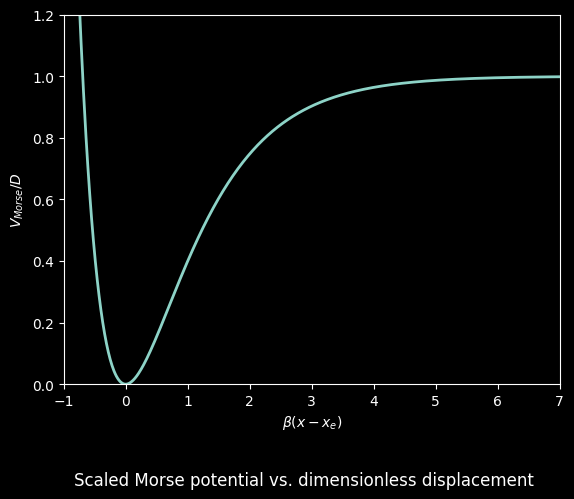

In [4]:
plt.figure(1)
t = np.arange(-1.0,7.0,0.01)
s = (1 - np.exp(-t))**2
line, = plt.plot(t,s,lw=2)
plt.ylim(0,1.2)
plt.xlim(-1.0,7.0)

plt.figtext(0.5,-0.1,"Scaled Morse potential vs. dimensionless displacement", ha='center', fontsize=12)
plt.xlabel(r'$\beta(x-x_e)$')
plt.ylabel(r'$V_{Morse} / D$')
plt.show()

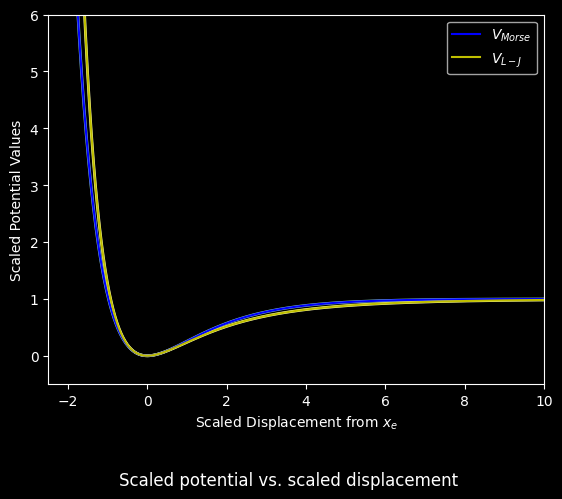

In [5]:
plt.figure(2)
t = np.arange(-5.0,20.0,0.01)
s = (1 - np.exp(-(t)/np.sqrt(2)))**2
line, = plt.plot(t,s,lw=2)

b = 4*((6*np.cbrt(2)/(t+6*np.sqrt(2)))**12-(6*np.cbrt(2)/(t+6*np.sqrt(2)))**6)+1
line, = plt.plot(t,b,lw=2)

plt.ylim(-0.5,6)
plt.xlim(-2.5,10.0)

plt.plot(t, s, "-b", label=r'$V_{Morse}$')
plt.plot(t, b, "-y", label=r'$V_{L-J}$')
plt.legend(loc="upper right")

plt.figtext(0.5,-0.1,"Scaled potential vs. scaled displacement", ha='center', fontsize=12)
plt.xlabel("Scaled Displacement from "r'$x_e$')
plt.ylabel("Scaled Potential Values")
plt.show()



In [6]:
N = sym.Symbol('N',real=True)
phi = sym.Symbol('phi',real=True)
theta = sym.Symbol('theta',real=True)
r =sym.Symbol('r',real=True)
a =sym.Symbol('a_0',real=True)

psi = N*sym.exp(-r/a)
psi

In [7]:
f = psi**2 * r**2 * sym.sin(theta)
G = Integral(f,(phi,0,2*sym.pi),(theta,0,sym.pi))
G.doit()

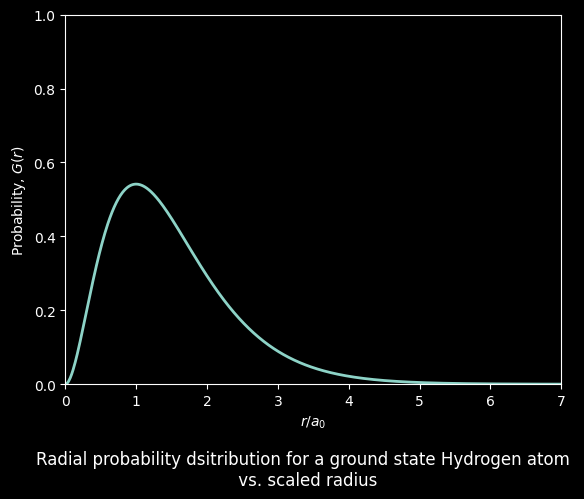

In [8]:
fig, ax = plt.subplots()
t = np.arange(-1.0,7.0,0.01)
s = 4*(t**2 * np.exp(-2*t))
line, = plt.plot(t,s,lw=2)
plt.ylim(0,1.0)
plt.xlim(0.0,7.0)

plt.figtext(0.5,-0.1,"Radial probability dsitribution for a ground state Hydrogen atom \n vs. scaled radius", ha='center', fontsize=12)
plt.ylabel(r'Probability, $G(r)$')
plt.xlabel(r'$r/a_0$')


plt.show()

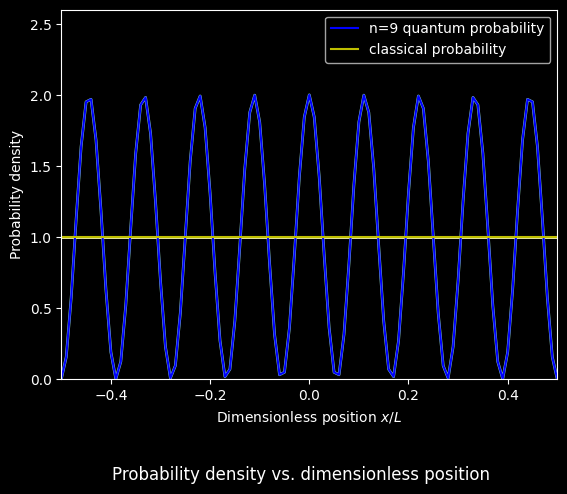

In [9]:
plt.figure(2)
t = np.arange(-0.6,2.0,0.01)
s = (np.sqrt(2)*np.cos(9*np.pi*t))**2
line, = plt.plot(t,s,lw=2)

b = t/t
line, = plt.plot(t,b,lw=2)

plt.ylim(0,2.6)
plt.xlim(-0.5,0.5)

plt.plot(t, s, "-b", label= "n=9 quantum probability")
plt.plot(t, b, "-y", label= "classical probability")
plt.legend(loc="upper right")

plt.figtext(0.5,-0.1,"Probability density vs. dimensionless position", ha='center', fontsize=12)
plt.xlabel("Dimensionless position "r'$x/L$')
plt.ylabel("Probability density")
plt.show()

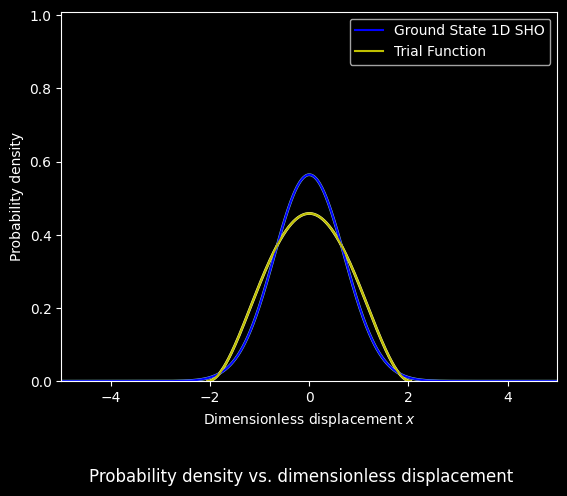

In [10]:
plt.figure(2)
t = np.arange(-5.1,5.1,0.01)
s = ((np.pi ** (-1/4))*np.exp(-t ** 2 /2))**2
line, = plt.plot(t,s,lw=2)

a = (35/2)**(1/4)

t2 = np.arange(-a,a,0.01)
b = 15/16*1/a**5*(t2**2-a**2)**2
line, = plt.plot(t2,b,lw=2)

plt.ylim(0,1.01)
plt.xlim(-5,5)

plt.plot(t, s, "-b", label= "Ground State 1D SHO")
plt.plot(t2, b, "-y", label= "Trial Function")
plt.legend(loc="upper right")

plt.figtext(0.5,-0.1,"Probability density vs. dimensionless displacement", ha='center', fontsize=12)
plt.xlabel("Dimensionless displacement "r'$x$')
plt.ylabel("Probability density")
plt.show()

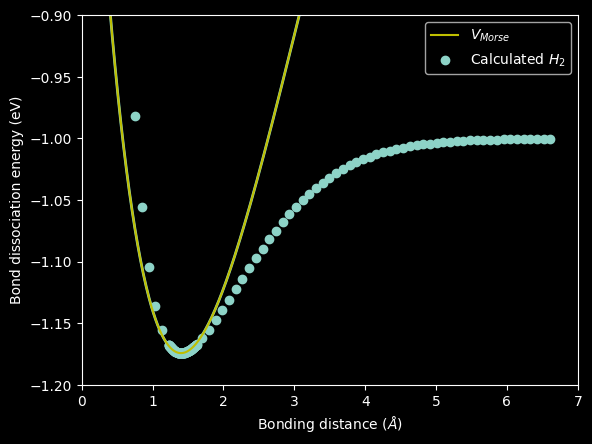

In [11]:
import csv

Rs = []
Es = []

with open('6zs.csv') as csvDataFile:
    csvReader = csv.reader(csvDataFile)
    itersk = iter(csvReader)
    next(itersk)
    for row in itersk:
        Rs.append(float(row[0]))
        Es.append(float(row[1]))

plt.figure(3)

k = 0.3676
D = 1.17434555
B = np.sqrt(k/(2*D))
R = 1.400287

t = np.arange(-5.0,20.0,0.01)
s = D*(np.exp(-2*B*(t-R))-2*np.exp(-B*(t-R)))
line, = plt.plot(t,s,lw=2)

plt.ylim(-1.2,-0.9)
plt.xlim(0.0,7.0)

plt.plot(t, s, "-y", label=r'$V_{Morse}$')
plt.scatter(Rs, Es, label='Calculated 'r'$H_2$')
plt.legend(loc="upper right")

plt.xlabel("Bonding distance "r'$(\AA)$')
plt.ylabel("Bond dissociation energy (eV)")
plt.show()

C:\Users\petrov\AppData\Local\Temp\ipykernel_22956\2384703777.py:6: RuntimeWarning: overflow encountered in exp
  s = (a1/t)**2*(np.exp(-a1/t)/(np.exp(-a1/t)-1)**2)
C:\Users\petrov\AppData\Local\Temp\ipykernel_22956\2384703777.py:6: RuntimeWarning: invalid value encountered in divide
  s = (a1/t)**2*(np.exp(-a1/t)/(np.exp(-a1/t)-1)**2)
C:\Users\petrov\AppData\Local\Temp\ipykernel_22956\2384703777.py:11: RuntimeWarning: overflow encountered in exp
  b = (a2/t)**2*(np.exp(-a2/t)/(np.exp(-a2/t)-1)**2)
C:\Users\petrov\AppData\Local\Temp\ipykernel_22956\2384703777.py:11: RuntimeWarning: invalid value encountered in divide
  b = (a2/t)**2*(np.exp(-a2/t)/(np.exp(-a2/t)-1)**2)


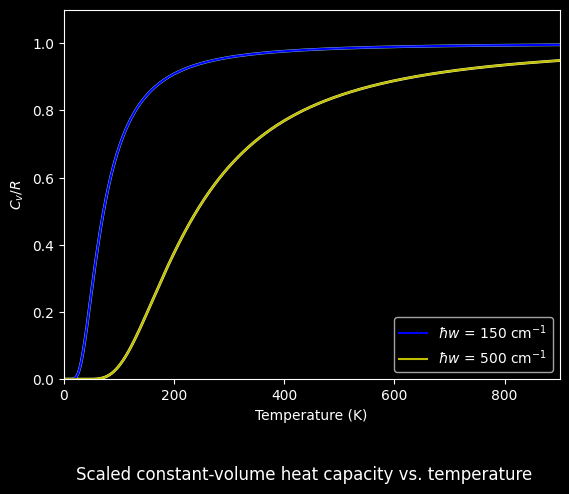

In [24]:
plt.figure(68)

a1 = 215.768091673

t = np.arange(-0.1,900,1)
s = (a1/t)**2*(np.exp(-a1/t)/(np.exp(-a1/t)-1)**2)
line, = plt.plot(t,s,lw=2)

a2 = 719.226972243

b = (a2/t)**2*(np.exp(-a2/t)/(np.exp(-a2/t)-1)**2)
line, = plt.plot(t,b,lw=2)

plt.ylim(0,1.1)
plt.xlim(-0.1,900)

plt.plot(t, s, "-b", label= r'$\hbar w$'" = 150 cm"r'$^{-1}$')
plt.plot(t, b, "-y", label= r'$\hbar w$'" = 500 cm"r'$^{-1}$')
plt.legend(loc="lower right")

plt.figtext(0.5,-0.1,"Scaled constant-volume heat capacity vs. temperature", ha='center', fontsize=12)
plt.xlabel("Temperature (K)")
plt.ylabel(r'$C_v/R$')
plt.show()